/local/scratch/181210/ipykernel_638098/4066817042.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Total Squares: 7040
Total Unique Videos: 15
Total Unique Boards: 110


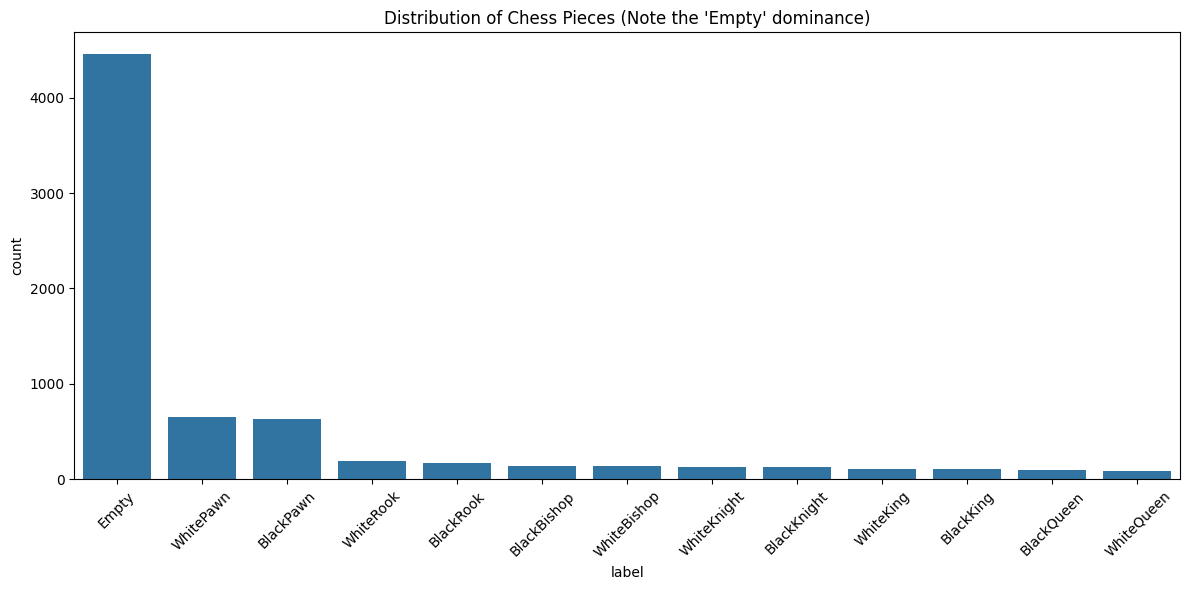

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_DIR = "dataset"
df = pd.read_csv(DATASET_DIR + "/dataset_metadata.csv")

# 1. Basic Counts
total_images = len(df)
num_videos = df['video_id'].nunique()
# Group by video and board to get unique boards
num_boards = df.groupby(['video_id', 'board']).ngroups 

print(f"Total Squares: {total_images}")
print(f"Total Unique Videos: {num_videos}")
print(f"Total Unique Boards: {num_boards}")

# 2. Piece Distribution (Class Imbalance Check)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title("Distribution of Chess Pieces (Note the 'Empty' dominance)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("piece_distribution.png")
plt.show()

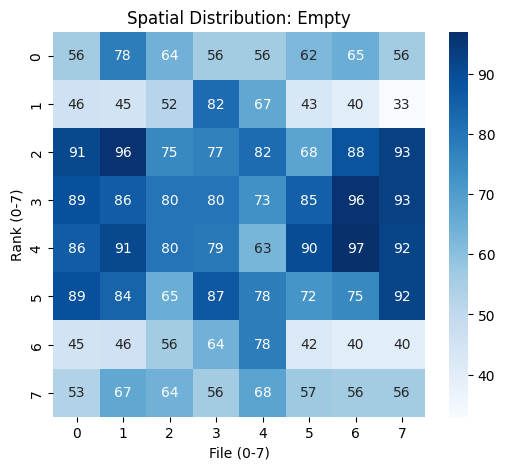

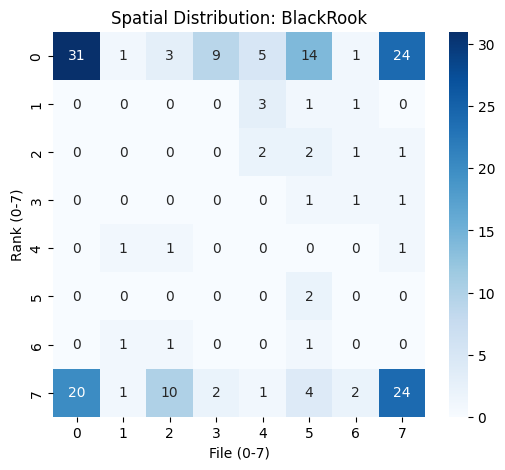

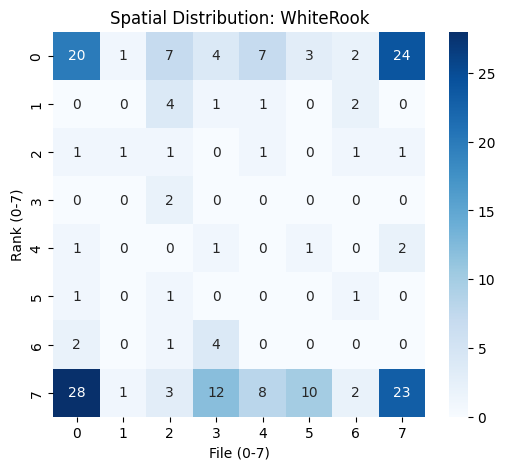

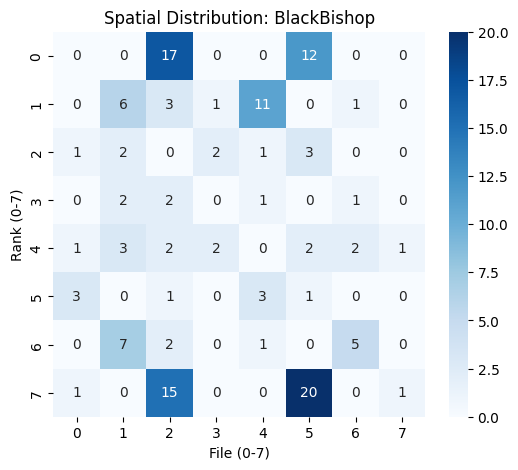

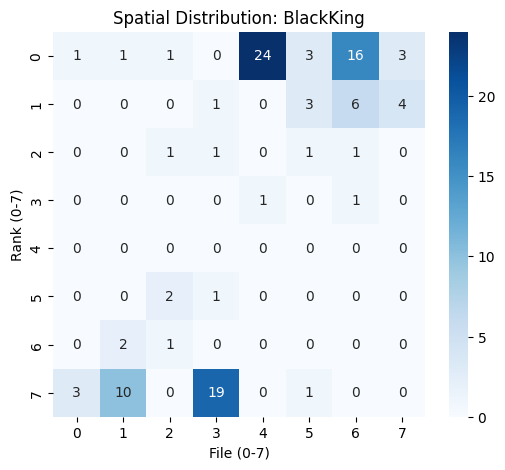

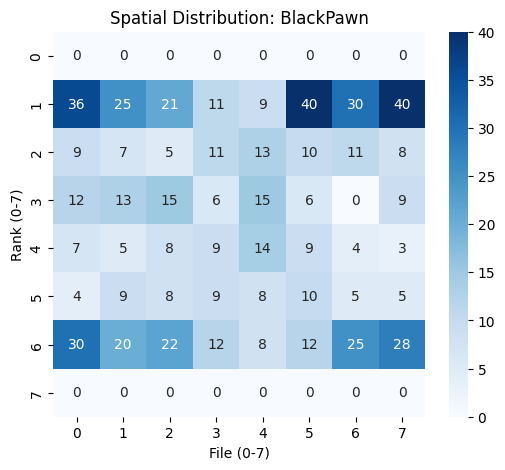

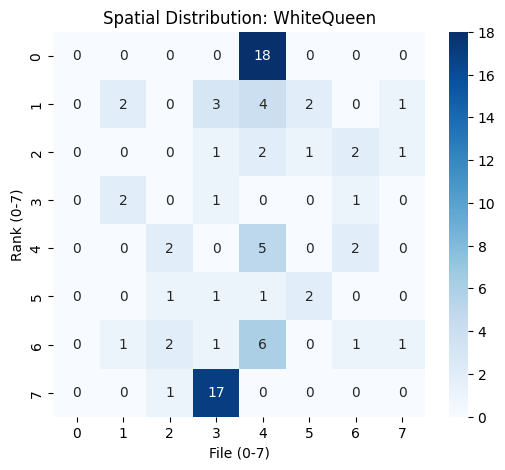

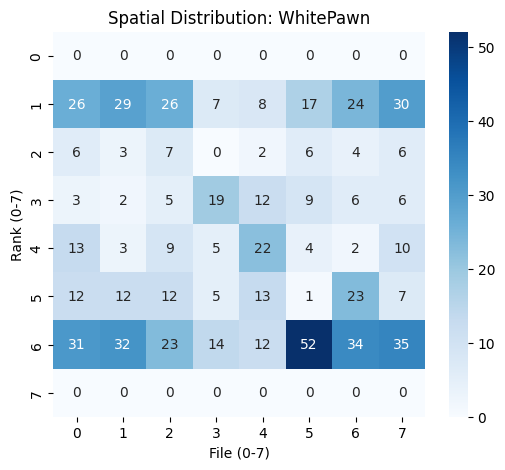

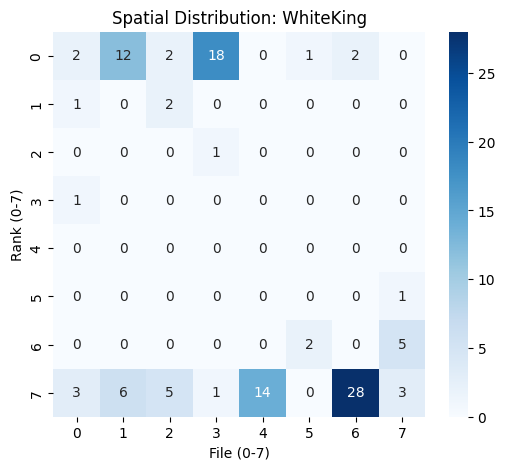

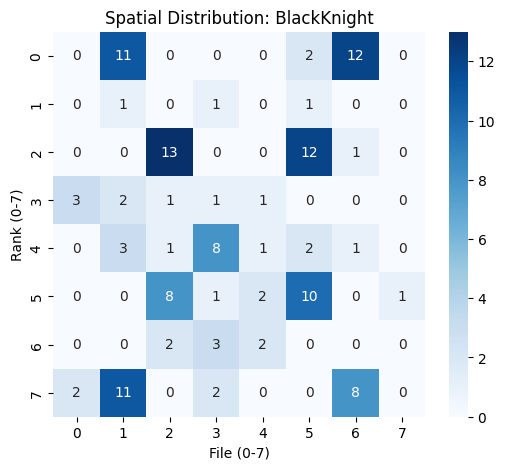

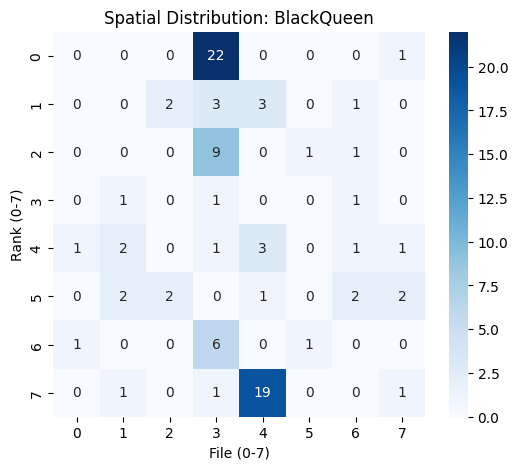

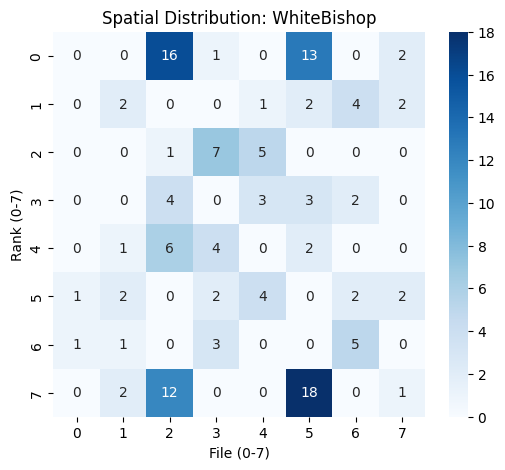

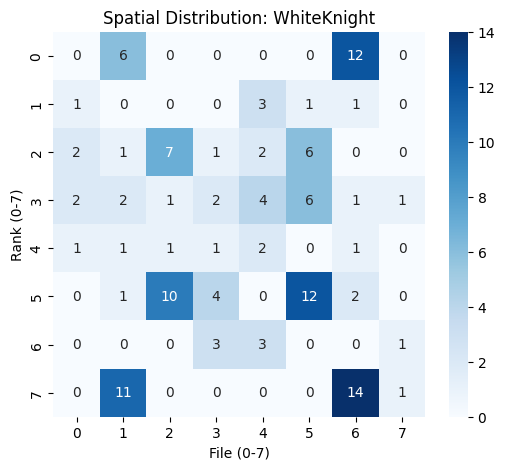

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure rank and file are integers
df['rank'] = df['rank'].astype(int)
df['file'] = df['file'].astype(int)

def plot_piece_heatmap(dataframe, piece_name):
    # Filter for the specific piece
    piece_df = dataframe[dataframe['label'] == piece_name]
    
    # Create an 8x8 matrix of counts
    heatmap_data = np.zeros((8, 8))
    for _, row in piece_df.iterrows():
        # Assuming rank 0-7 and file 0-7. Adjust indices if your logic is different.
        heatmap_data[row['rank'], row['file']] += 1
        
    plt.figure(figsize=(6, 5))
    sns.heatmap(heatmap_data, annot=True, fmt="g", cmap="Blues", cbar=True)
    plt.title(f"Spatial Distribution: {piece_name}")
    plt.xlabel("File (0-7)")
    plt.ylabel("Rank (0-7)")
    plt.show()

# Test to verify game logic
for piece_name in df['label'].unique():
    plot_piece_heatmap(df, piece_name)

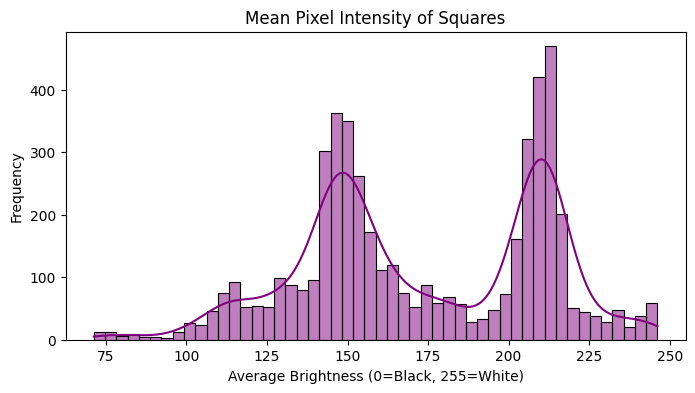

In [3]:
import cv2
import os

# Let's sample a subset if the dataset is massive
sample_df = df.sample(n=min(5000, len(df)), random_state=42)
mean_intensities = []

for filepath in sample_df['filepath']:
    img_path = os.path.join(DATASET_DIR, filepath)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        # Calculate the average pixel brightness
        mean_intensities.append(img.mean())

plt.figure(figsize=(8, 4))
sns.histplot(mean_intensities, bins=50, kde=True, color='purple')
plt.title("Mean Pixel Intensity of Squares")
plt.xlabel("Average Brightness (0=Black, 255=White)")
plt.ylabel("Frequency")
# You should ideally see a bimodal distribution (two peaks)!
plt.show()